# CVaR 95% deep hedging: Table 1 and Figure 1

Amanjeet Singh

Independent numerical replication of the 95% experiment in *Is the difference between deep hedging and delta hedging a statistical arbitrage?*.

Only the **95% agent** is trained. The report supplies the complete derivations and all numerical assumptions. This notebook executes the calibration and mathematical checks and recomputes all four statistics and figures from the supplied untouched test outcomes. The optional switches rerun the expensive simulation/training stages; the saved checkpoint is the result of the full 400,000-path, 50-epoch experiment. Exact recovery of the authors' unpublished calibration, weights and seeds is not claimed.

Install `requirements.txt` and run this notebook from the repository root.

In [1]:
from pathlib import Path
import json, sys, math, runpy
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Image

ROOT = Path.cwd()
assert (ROOT / "replication.py").is_file(), "Run from the extracted reproduction folder"
sys.path.insert(0, str(ROOT))
from replication import Config, Hedger, physical_paths, cvar, cvar_influence, configure_torch, train, risk_neutral_price
from calibrate import calibrate
from evaluate import evaluate, plot_results

# Optional expensive steps. Defaults replay the supplied completed experiment.
REFIT = True
REPRICE = True
RETRAIN = False
REEVALUATE = False
configure_torch(1)
calibration = json.loads((ROOT / "calibration.json").read_text())
params = calibration["selected_parameters"]
cfg = Config()
print("Python", sys.version.split()[0], "NumPy", np.__version__, "PyTorch", torch.__version__)
display(pd.Series(params, name="Exact selected daily parameters"))

Python 3.12.14 NumPy 2.3.5 PyTorch 2.5.1


mu                  0.000625
omega               0.000003
alpha               0.100000
gamma               0.199999
beta                0.780000
initial_variance    0.000026
Name: Exact selected daily parameters, dtype: float64

## 1. Data and calibration

Use the authors' repository at commit `ac76f29ab6fb9379df11b3e9087dd8023c2cbf5d`. Select rows `5031:` of the supplied price file **before** differencing; retain the 31 December 2015 close to calculate the first return on 4 January 2016. There are 1,259 log returns through 31 December 2020.

For $\epsilon_t=R_t-\mu$, the likelihood is $-\tfrac12\sum_t[\log(2\pi)+\log h_t+\epsilon_t^2/h_t]$, with $h_{t+1}=\omega+(a+g\mathbf1_{\epsilon_t<0})\epsilon_t^2+b h_t$. `arch` 8.0.0 supplies its documented backcast, variance bounds and optimiser defaults. The raw-return fit follows the authors' code; the 100-times scaled fit is a conditioning diagnostic. Simulation starts from the raw fit's final variance, an explicit assumption because the paper does not precisely identify its initial state. The next historical forecast is reported separately.

In [2]:
if REFIT:
    recalibration = calibrate(ROOT / "data/SP500_random.csv")
    refitted = recalibration["selected_parameters"]
    for key in params:
        np.testing.assert_allclose(refitted[key], params[key], rtol=1e-9, atol=1e-12)
    print("Refit reproduces all supplied selected parameters.")
    display(pd.DataFrame({
        "raw fit": recalibration["authors_unscaled_fit"]["params_decimal_returns"],
        "scaled diagnostic": recalibration["scaled_conditioning_control"]["params_decimal_returns"]
    }))
else:
    print("Using supplied full-precision calibration.")

Refit reproduces all supplied selected parameters.


,raw fit,scaled diagnostic
mu,0.000625,0.000682
omega,0.000003,0.000004
alpha[1],0.100000,0.147310
gamma[1],0.199999,0.230700
beta[1],0.780000,0.720777


## 2. Physical simulation and self-financing wealth

At decision $t$, $h_t$ denotes the **known variance of return $t+1$**. Draw $z_{t+1}\sim N(0,1)$ and apply
$$R_{t+1}=\mu+\sqrt{h_t}z_{t+1},\quad S_{t+1}=S_te^{R_{t+1}},\quad h_{t+1}=\omega+h_t(a+g\mathbf1_{z_{t+1}<0})z_{t+1}^2+b h_t.$$
For cash $C_t=V_t-\delta_tS_t$, continuous dividend reinvestment yields
$$V_{t+1}=e^{r/252}C_t+\delta_te^{q/252}S_{t+1}=e^{r/252}V_t+\delta_tG_{t+1},\quad G_{t+1}=e^{q/252}S_{t+1}-e^{r/252}S_t.$$
The constraint $C_t\ge-B$ gives $\delta_t\le(V_t+B)/S_t$. The agent implements $\min(f_\theta,(V_t+B)/S_t)$; there is no lower stock-position constraint. Both strategies start with the paper's capital 3.16, $S_0=K=100$, $T=63$, $B=100$, $r=.0167$, $q=.0165$, and zero transaction costs.

In [3]:
checks = runpy.run_path(str(ROOT / "verify_replication.py"))["results"]
assert all(v["passed"] for v in checks.values())
display(pd.DataFrame(checks).T)
small_cfg = Config(maturity=7)
features, gains, payoff = physical_paths(1000, params, small_cfg, seed=123)
assert features.shape == (1000, 7, 3)
assert gains.shape == (1000, 7)
assert np.isfinite(features).all() and np.isfinite(gains).all()
print("Path shapes, known initial state, predictability, cash recurrence, cap, CVaR gradient and overlay identity checked.")

{
  "seed_reproducibility": {
    "passed": true
  },
  "known_initial_state": {
    "passed": true
  },
  "cash_account_0.3": {
    "passed": true,
    "max_abs_error": 1.8902837606304956e-07
  },
  "borrowing_constraint_0.3": {
    "passed": true,
    "minimum_cash": -26.840003967285156
  },
  "cash_account_-0.5": {
    "passed": true,
    "max_abs_error": 4.778112483450059e-07
  },
  "borrowing_constraint_-0.5": {
    "passed": true,
    "minimum_cash": 53.160003662109375
  },
  "cash_account_1000.0": {
    "passed": true,
    "max_abs_error": 3.745785903674914e-07
  },
  "borrowing_constraint_1000.0": {
    "passed": true,
    "minimum_cash": -100.00000762939453
  },
  "cvar_gradient": {
    "passed": true,
    "autograd": -3.39935302734375,
    "analytic": -3.399352815553119
  },
  "cvar_tail": {
    "passed": true
  },
  "overlay_wealth_identity": {
    "passed": true,
    "max_absolute_residual": 8.881784197001252e-16
  },
  "torchscript_terminal_wealth": {
    "passed": true,
 

,passed,max_abs_error,minimum_cash,autograd,analytic,max_absolute_residual
seed_reproducibility,True,NaN,NaN,NaN,NaN,NaN
known_initial_state,True,NaN,NaN,NaN,NaN,NaN
cash_account_0.3,True,0.0,NaN,NaN,NaN,NaN
borrowing_constraint_0.3,True,NaN,-26.840004,NaN,NaN,NaN
cash_account_-0.5,True,0.0,NaN,NaN,NaN,NaN
borrowing_constraint_-0.5,True,NaN,53.160004,NaN,NaN,NaN
cash_account_1000.0,True,0.0,NaN,NaN,NaN,NaN
borrowing_constraint_1000.0,True,NaN,-100.000008,NaN,NaN,NaN
cvar_gradient,True,NaN,NaN,-3.399353,-3.399353,NaN
cvar_tail,True,NaN,NaN,NaN,NaN,NaN


Path shapes, known initial state, predictability, cash recurrence, cap, CVaR gradient and overlay identity checked.


## 3. Risk-neutral price and the initial-state ambiguity

Set $c=(r-q)/252$ and $\eta_t=(\mu-c+h_t/2)/\sqrt{h_t}$. Under $Q$, draw $z^Q\sim N(0,1)$:
$$R=c-h_t/2+\sqrt{h_t}z^Q,\quad h_{t+1}=\omega+h_t(a+g\mathbf1_{z^Q-\eta_t<0})(z^Q-\eta_t)^2+b h_t.$$
Thus $E_Q[e^R\mid\mathcal F_t]=e^c$ and $C_0=e^{-rT/252}E_Q[(S_T-K)^+]$. For a bounded estimator, use put–call parity:
$$C_0=S_0e^{-qT/252}-Ke^{-rT/252}+P_0,\quad P_0=e^{-rT/252}E_Q[(K-S_T)^+].$$
The put payoff lies in $[0,K]$. Simulate 62 periods with antithetic innovations, integrate the final conditional Gaussian period using $P_1=Ke^{-r/252}\Phi(-d_2)-Se^{-q/252}\Phi(-d_1)$, and discount that conditional put over the preceding 62 periods. Here $d_1=[\log(S/K)+(r-q)/252+h/2]/\sqrt h$ and $d_2=d_1-\sqrt h$. The bounded discounted put has finite variance; its pair-based standard error is also the call estimator's standard error, because the parity adjustment is deterministic. Use independent **pair averages**, not individual correlated paths. This avoids assuming a finite second moment for the unbounded call payoff.

The selected historical state does not reproduce 3.16. A separate **price-compatible initial-state illustration**, with the same fitted coefficients, shows that the price can be matched; it was chosen after a price bracket and is not used to train the reported agent. The alternative cannot identify the original initial variance or establish a full replication.

In [4]:
price = json.loads((ROOT / "price_validation.json").read_text())
if REPRICE:
    computed = risk_neutral_price(params, cfg, n=2_000_000)
    np.testing.assert_allclose(computed["price"], price["price"], rtol=0, atol=1e-12)
    print("Recomputed selected-model price:", computed)
display(pd.Series(price, name="Selected-model price check"))
audit = json.loads((ROOT / "stable_price_matching_audit.json").read_text())
scenarios = audit["scenarios"]
display(pd.DataFrame([{k:v for k,v in row.items() if k in
    ["label", "first_return_conditional_variance", "price", "standard_error_antithetic_pairs", "ci95", "seed", "price_3p16_in_ci95"]}
    for row in scenarios]))

Recomputed selected-model price: {'price': np.float64(2.7700684349135973), 'standard_error': 0.0029763686932246726, 'paths': 2000000, 'put_price': 2.765089141916335, 'parity_term': 0.004979292997262519, 'estimator_note': 'Bounded final-period conditional put plus put-call parity; price SE equals antithetic put-pair SE', 'bound_stats': {'lower': 0.0, 'upper': 99.5833703196339, 'sample_min': 0.0, 'sample_max': 99.5833703196339, 'violations': 0}, 'antithetic_pairs': 1000000, 'discounted_dividend_stock_mean': np.float64(100.0002181721257), 'final_period_integrated_analytically': True, 'simulated_periods': 62, 'absorbed_numerically_zero_stock_paths': 1, 'paths_dropped': 0, 'variance_clipped': False, 'max_live_variance': 5022.636133893306}


price                                                                             2.770068
standard_error                                                                    0.002976
paths                                                                              2000000
put_price                                                                         2.765089
parity_term                                                                       0.004979
estimator_note                           Bounded final-period conditional put plus put-...
bound_stats                              {'lower': 0.0, 'upper': 99.5833703196339, 'sam...
antithetic_pairs                                                                   1000000
discounted_dividend_stock_mean                                                  100.000218
final_period_integrated_analytically                                                  True
simulated_periods                                                                       62

,price,label,first_return_conditional_variance,standard_error_antithetic_pairs,ci95,seed,price_3p16_in_ci95
0,2.770068,source_coeffs_h0_multiple_1,0.000026,0.002976,"[2.764234752274877, 2.7759021175523175]",46,False
1,2.978164,source_coeffs_h0_multiple_2,0.000052,0.003224,"[2.971843956328024, 2.9844830736741828]",46,False
2,3.166004,source_coeffs_h0_multiple_3,0.000078,0.003447,"[3.1592478708549185, 3.1727600187080007]",46,True
3,3.339455,source_coeffs_h0_multiple_4,0.000104,0.003650,"[3.332300350107486, 3.346609006872728]",46,False
4,3.151578,rounding_witness_half_upper_interval,0.000026,0.003536,"[3.144647471247992, 3.1585090473638524]",46,False
5,3.160828,illustrative_unreported_initial_variance_7p75e...,0.000077,0.003441,"[3.1540837690344152, 3.1675719866987078]",46,True
6,3.161292,illustrative_unreported_initial_variance_7p75e...,0.000077,0.003440,"[3.154549303974553, 3.1680348979905815]",47,True


## 4. Delta benchmark

Holding the initial conditional variance fixed, the risk-neutral state recursion is independent of current spot and $S_T=S_tX$, so
$$\Delta=e^{-r\tau/252}E_Q[(S_T/S_t)\mathbf1_{S_T>K}].$$
Define the stock measure by $dQ^S/dQ=e^{-(r-q)\tau/252}S_T/S_t$. Then $\Delta=e^{-q\tau/252}Q^S(S_T>K)$. The one-step exponential density tilt shifts $z^Q$ to $N(\sqrt h,1)$, while the variance transition still uses $z^Q-\eta$.

The full recursion is in `delta_reference.py`: exact one-day normal CDF; backward 48-node Gaussian-Hermite integration; bilinear interpolation on log-moneyness and log-variance; a fine grid and a wider auxiliary grid for $h>.01$. This deterministic, validated numerical method differs from the authors' 1,000-path nested Monte Carlo benchmark. Evaluation rebuilds the delta grid in memory.

In [5]:
delta_validation = json.loads((ROOT / "delta_validation.json").read_text())
print(delta_validation.get("report_summary", "Detailed quadrature and independent Monte Carlo diagnostics are in delta_validation.json."))
print("Numerical algorithm: delta_reference.py")

Detailed quadrature and independent Monte Carlo diagnostics are in delta_validation.json.
Numerical algorithm: delta_reference.py


## 5. CVaR training and the selected checkpoint

For $L=(S_T-K)^+-V_T$, $\mathrm{CVaR}_{.95}(L)=\min_u[u+E(L-u)^+/.05]$. At a continuous distribution the minimiser is its 95% quantile. In a minibatch of 1,000 paths the implemented objective is the mean of the **50 largest losses**; its almost-everywhere gradient is the mean of their loss gradients.

The state is $(\log S_t,(T-t)/252,\sqrt{252h_t},V_t)$. A shared network has four hidden layers of 56 ReLU units, linear output, Glorot-uniform weights and zero biases. Adam uses learning rate .0005, betas (.9,.999), epsilon $10^{-8}$, no dropout and no transaction costs. Train on 400,000 fixed physical paths for 50 shuffled epochs (batch 1,000). Select the lowest CVaR checkpoint on a separate 50,000-path validation sample. Seeds are train 43, validation 44, test 45, network 4301 and shuffle 1043. The untouched 100,000-path test is evaluated after checkpoint selection.

In [6]:
folder = ROOT / "run95"
if RETRAIN:
    folder = ROOT / "retrained95"
    train(params, cfg, folder, device="cpu", threads=1)
if REEVALUATE or RETRAIN:
    evaluate(folder)  # Builds the exact fine and auxiliary delta grids in RAM.
history = pd.read_json(folder / "training_history.json")
assert len(history) == 50 and history.iloc[-1]["epoch"] == 50
results = json.loads((folder / "results.json").read_text())
ck = torch.load(folder / "agent95.pt", map_location="cpu", weights_only=False)
assert ck["epoch"] == results["best_epoch"]
assert ck["config"]["confidence"] == .95
print("Selected epoch:", ck["epoch"], "Validation CVaR95:", ck["validation_cvar"])
display(history.loc[history["epoch"].isin([1, ck["epoch"], 50])])

Selected epoch: 31 Validation CVaR95: 2.9052255080223084


,epoch,training_cvar,validation_cvar,best_validation_cvar,seconds
0,1,4.065191,3.200149,3.200149,31.007353
30,31,2.946565,2.905226,2.905226,25.691257
49,50,2.975403,2.925704,2.905226,25.087499


## 6. Zero-capital difference strategy and uncertainty

For predictable positions $\delta_t^{A}=\delta_t^{DH}-\delta_t^\Delta$, initialize $V_0^A=0$ and use the same wealth recursion. Subtracting the two recursions gives $V_T^A=V_T^{DH}-V_T^\Delta=L^\Delta-L^{DH}$ because both standalone hedges have the same initial capital and option payoff. Consequently $L^{DH}=L^\Delta-V_T^A$. **The difference between two CVaRs is not the CVaR of their difference.**

Calculate the Table 1 row as $(\mathrm{CVaR}_{.95}(L^{DH}),\mathrm{CVaR}_{.95}(L^{DH})-\mathrm{CVaR}_{.95}(L^\Delta),\mathrm{CVaR}_{.95}(-V_T^A),E[V_T^A])$.

For $v=\mathrm{VaR}_{.95}(L)$, the centered influence values are $\psi_i=(L_i-v)^+/.05-\overline{(L-v)^+/.05}$. Their sample standard deviation divided by $\sqrt N$ gives a plug-in CVaR standard error. Use paired $\psi^{DH}-\psi^\Delta$ for the risk gap and ordinary mean standard error for P&L. The reported normal intervals assume finite second moments of the relevant influences; those moments are not established for the hedge losses.

The physical Gaussian GJR stock has no finite first moment from three periods onward. On $z_1,z_2>0$, $h_1\ge\alpha h_0z_1^2$ and $h_2\ge\alpha^2h_0z_1^2z_2^2$. Integrating $z_3$ gives $E[S_3\mid z_1,z_2]=S_0\exp(3\mu+\sqrt{h_0}z_1+\sqrt{h_1}z_2+h_2/2)$. On the strip $z_1=x$, $z_2\in[x,x+1]$, its Gaussian-weighted integral is bounded below by a positive constant times $\int_R^\infty\exp[(\alpha^2h_0/2)x^4-x^2-x-1/2]\,dx=\infty$. Nonnegativity permits Tonelli's theorem. The conditional stock mean $S_t\exp(\mu+h_t/2)\ge e^\mu S_t$ propagates this to later dates. The unhedged call payoff therefore has infinite physical mean. **This does not by itself prove infinite moments of hedging losses or the difference strategy**, because hedge wealth can cancel stock-payoff tails. The reported hedge statistics are finite Monte Carlo sample estimates, with empirical plug-in intervals rather than proven population coverage.

In [7]:
with np.load(folder / "terminal_results.npz") as a:
    dh_loss = a["deep_loss"]
    delta_loss = a["delta_loss"]
    overlay = a["overlay_pnl"]
N = len(overlay)
assert N == 100_000
np.testing.assert_allclose(dh_loss, delta_loss-overlay, rtol=0, atol=1e-8)
se = lambda x: np.std(x, ddof=1)/np.sqrt(N)
point = [cvar(dh_loss), cvar(dh_loss)-cvar(delta_loss), cvar(-overlay), overlay.mean()]
errors = [se(cvar_influence(dh_loss)), se(cvar_influence(dh_loss)-cvar_influence(delta_loss)),
          se(cvar_influence(-overlay)), se(overlay)]
for row, estimate, error in zip(results["metrics"], point, errors):
    np.testing.assert_allclose(row["estimate"], estimate, rtol=0, atol=1e-12)
    np.testing.assert_allclose(row["standard_error"], error, rtol=0, atol=1e-12)
table = pd.DataFrame(results["metrics"])[["name", "published", "estimate", "ci_low", "ci_high", "difference"]]
display(table.round(6))
print("CVaR95 statistical-arbitrage criterion satisfied:", cvar(-overlay)<0)
print("All supplied test checks:", results["checks"])

,name,published,estimate,ci_low,ci_high,difference
0,Deep hedging CVaR95 loss,3.481,2.884726,2.790608,2.978843,-0.596274
1,Deep minus delta CVaR95 loss,-0.081,-0.075220,-0.150799,0.000358,0.005780
2,Difference strategy CVaR95 loss,1.810,1.865054,1.812472,1.917635,0.055054
3,Difference strategy mean P&L,-0.254,-0.262780,-0.269389,-0.256170,-0.008780


CVaR95 statistical-arbitrage criterion satisfied: False
All supplied test checks: {'overlay_identity_max_error': 4.263256414560601e-14, 'hedging_loss_identity_max_error': 4.263256414560601e-14, 'torch_vs_float64_wealth_max_error': 2.037142351696275e-05, 'minimum_cash_float64': -100.00003353555076, 'minimum_cash_torch': -100.00001525878906, 'borrowing_limit_tolerance': 0.001, 'finite_test_losses': True, 'training_test_distinct_seeds': True, 'validation_test_distinct_seeds': True}


## 7. Figure 1 and training history

These are **frequency histograms of terminal difference-strategy wealth**, not densities or hedging losses. The central interval $[-5,5]$ and full-range logarithmic-frequency view contain the same test sample; the full view makes rare tails visible. No published histogram was digitised or used as a fitting target.

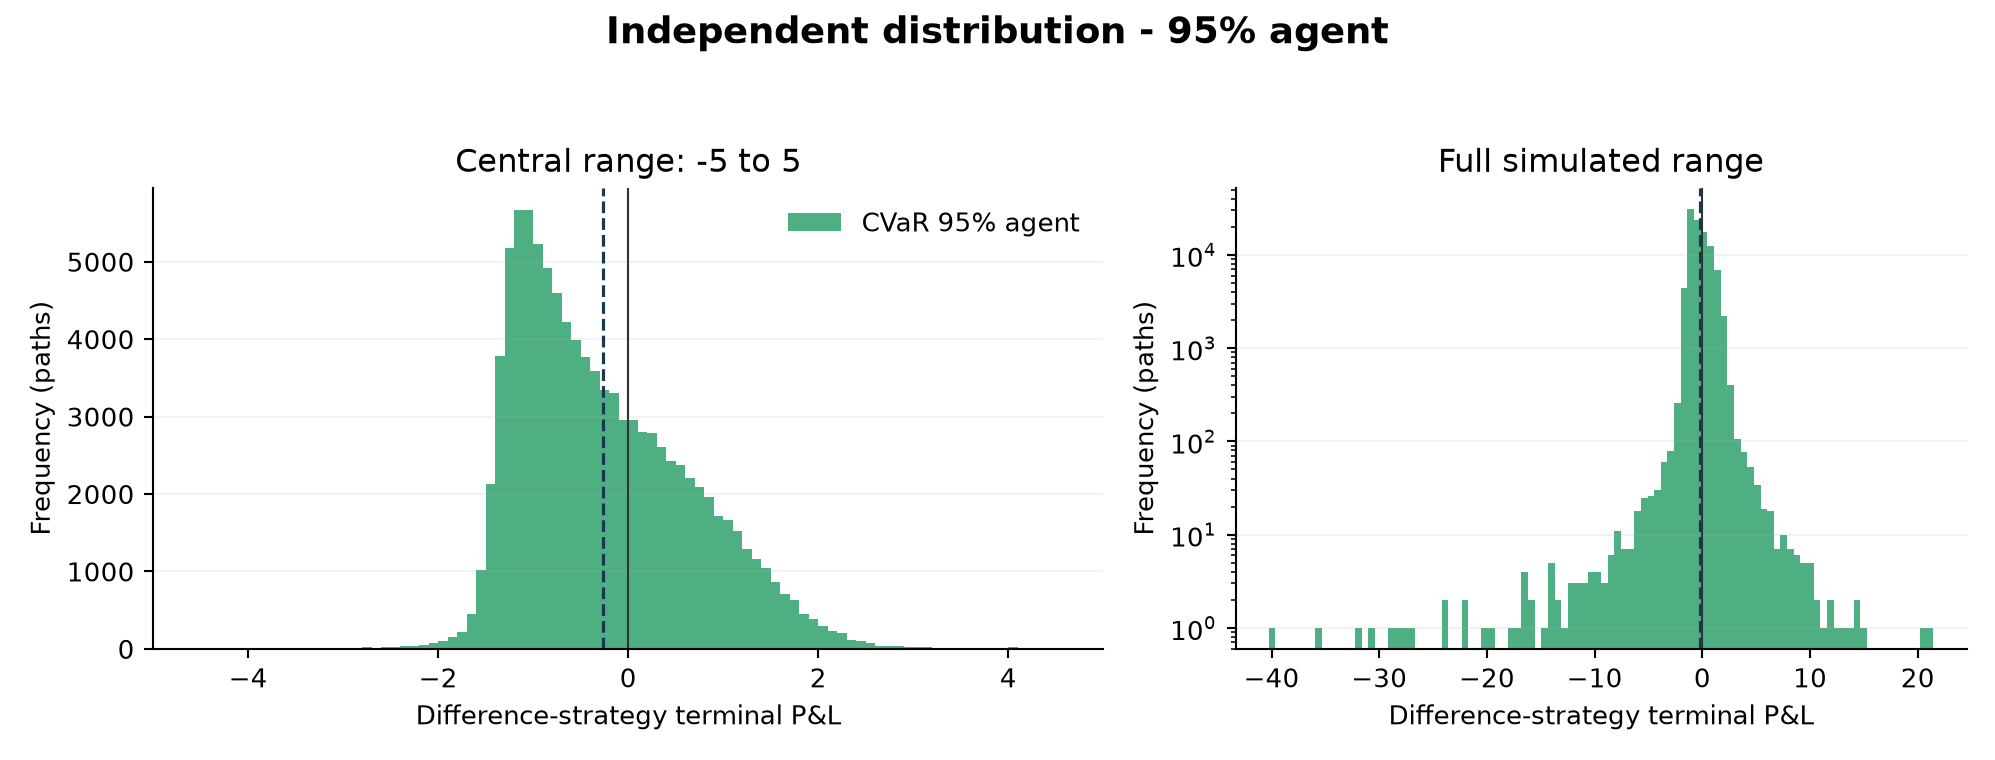

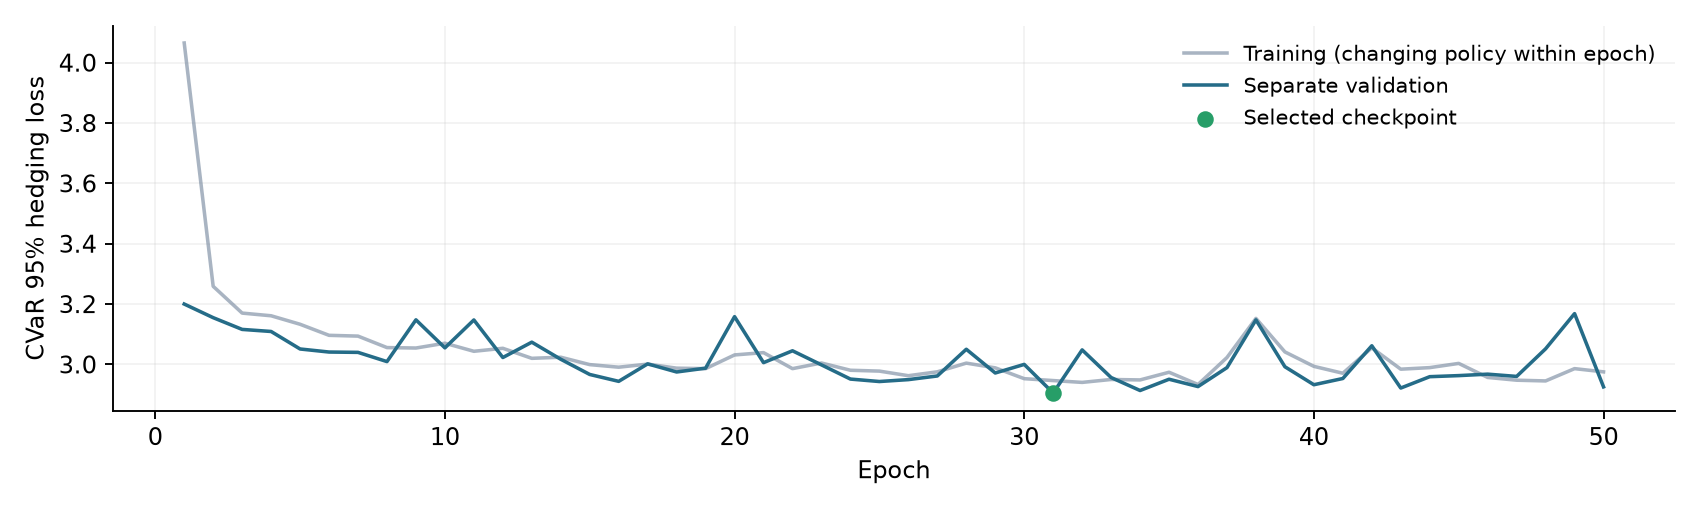

Central histogram paths: 99756 Outside central view: 244


In [8]:
plot_results(folder)
display(Image(filename=str(folder / "figure1_95.png")))
display(Image(filename=str(folder / "training_curve.png")))
bins = np.linspace(-5, 5, 101)
counts, _ = np.histogram(overlay, bins=bins)
supplied = np.loadtxt(folder / "figure1_histogram.csv", delimiter=",", skiprows=1)
np.testing.assert_array_equal(counts, supplied[:, 2])
print("Central histogram paths:", int(counts.sum()), "Outside central view:", N-int(counts.sum()))

## 8. Fidelity limits and full rerun

The independent run is completely specified, but the original published run is not recovered. Material differences are the refitted coefficients and initial variance, paper-equation state timing, PyTorch rather than TensorFlow, explicit seeds, separate validation rather than repeated selection on the authors' test set, and deterministic delta quadrature rather than nested Monte Carlo. The report details the price gap and source-code discrepancies. A price match alone does not validate hedge distributions or recover the original state.

To rerun **every computational stage**, install the pinned requirements and run:
```
python calibrate.py --data data/SP500_random.csv --output recalibration.json
python verify_replication.py
python price_audit.py
python replication.py --calibration calibration.json --folder retrained95 --epochs 50 --device cpu
python evaluate.py --folder retrained95
```
Alternatively set `REPRICE`, `RETRAIN` and `REEVALUATE` above to `True`. A full CPU training run took approximately half an hour on the recorded machine; delta-grid construction takes several additional minutes. Memory requirements are a few GB. Minor floating-point and optimiser differences across systems can alter a trained policy; supplied weights and test outcomes preserve the reported experiment exactly.